# Normalization Shootout on CIFAR-100

Building on the earlier BatchNorm exploration, this notebook tackles a tougher dataset (CIFAR-100) and compares three normalization strategies—BatchNorm, GroupNorm, and LayerNorm-style (group norm with 1 group). We track how each approach affects training stability, activation statistics, and gradient flow.

## Goals
- Train matched CNNs on CIFAR-100 with different normalization layers.
- Record per-layer activation summaries and gradient norms across epochs.
- Visualize the contrast in convergence speed and internal signal dynamics.

## 1. Imports, Reproducibility, and Device Info
Everything we need for data loading, modeling, logging, and visualization. We also fix seeds to keep comparisons stable.

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import torchvision
import matplotlib.pyplot as plt

sns.set_theme(context='talk', style='whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

SEED = 23
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def torch_manual_seed_all(seed: int):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

torch_manual_seed_all(SEED)

print(f'torch version: {torch.__version__}')
print(f'torchvision version: {torchvision.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

torch version: 2.8.0
torchvision version: 0.23.0
Using device: cpu


## 2. CIFAR-100 Data Pipeline
CIFAR-100 is more challenging than CIFAR-10 due to class diversity. To keep runtime reasonable we sub-sample while maintaining class coverage.

In [2]:
DATA_DIR = Path('cifar100_data')
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
])
train_dataset = datasets.CIFAR100(root=DATA_DIR, train=True, download=True, transform=transform)
val_dataset = datasets.CIFAR100(root=DATA_DIR, train=False, download=True, transform=transforms.ToTensor())

TRAIN_SIZE = 10000
VAL_SIZE = 2000
indices = torch.randperm(len(train_dataset))
train_subset = Subset(train_dataset, indices[:TRAIN_SIZE])
val_subset = Subset(val_dataset, torch.arange(VAL_SIZE))

BATCH_SIZE = 128
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
probe_loader = DataLoader(val_subset, batch_size=64, shuffle=False)
probe_inputs, probe_targets = next(iter(probe_loader))
probe_inputs, probe_targets = probe_inputs.to(device), probe_targets.to(device)

print(f'Subset sizes -> train: {len(train_subset)}, val: {len(val_subset)}')
print(f'Batches per epoch -> train: {len(train_loader)}, val: {len(val_loader)}')

  0%|          | 0.00/169M [00:00<?, ?B/s]

  0%|          | 65.5k/169M [00:00<05:23, 522kB/s]

  0%|          | 229k/169M [00:00<02:56, 954kB/s] 

  0%|          | 557k/169M [00:00<01:31, 1.84MB/s]

  1%|          | 1.28M/169M [00:00<00:44, 3.75MB/s]

...

 93%|█████████▎| 158M/169M [00:05<00:00, 37.9MB/s]

 96%|█████████▌| 162M/169M [00:05<00:00, 37.1MB/s]

 99%|█████████▊| 167M/169M [00:05<00:00, 38.7MB/s]

100%|██████████| 169M/169M [00:05<00:00, 31.1MB/s]

Subset sizes -> train: 10000, val: 2000
Batches per epoch -> train: 79, val: 16


## 3. Visual Check
A quick grid of CIFAR-100 samples reminds us how varied the task is.

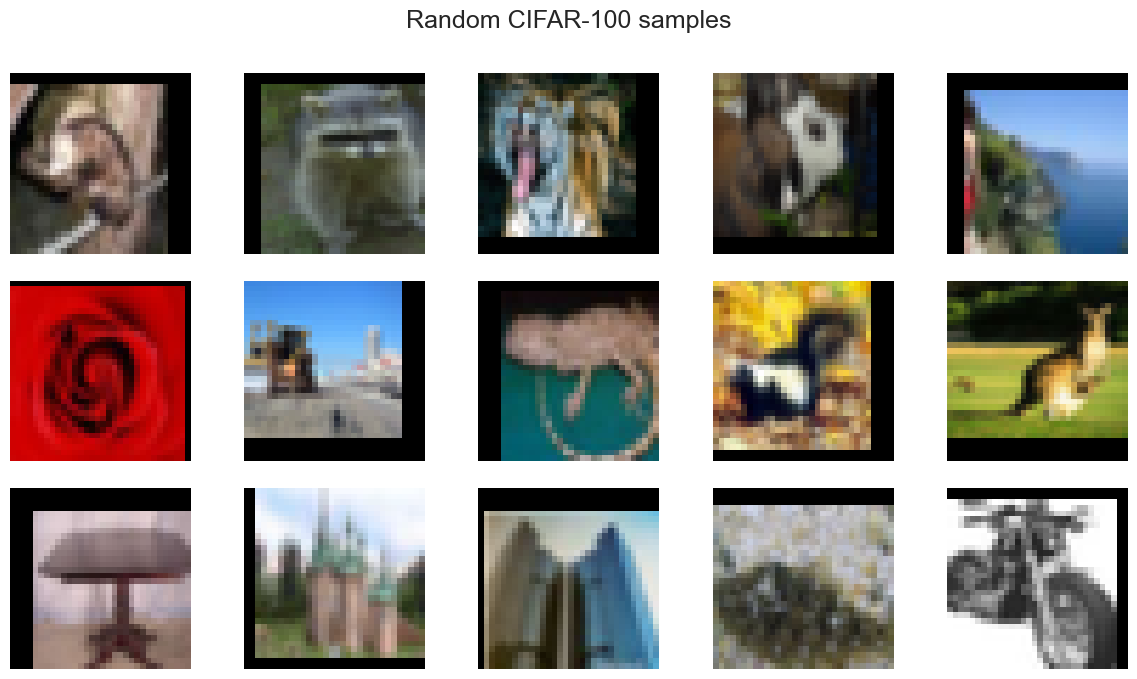

In [3]:
fig, axes = plt.subplots(3, 5, figsize=(12, 7))
for ax in axes.flatten():
    img, label = train_dataset[random.randrange(len(train_dataset))]
    ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    ax.axis('off')
fig.suptitle('Random CIFAR-100 samples', fontsize=18)
plt.tight_layout()
plt.show()

## 4. CNN Backbone with Configurable Normalization
We reuse the same architecture for all experiments and plug in different normalization layers after each learnable block.

In [4]:
NORMALIZATION_OPTIONS = ['batchnorm', 'groupnorm', 'layernorm']


def make_norm(channels: int, norm_type: str, dims: str = '2d'):
    if norm_type == 'batchnorm':
        return nn.BatchNorm2d(channels) if dims == '2d' else nn.BatchNorm1d(channels)
    if norm_type == 'groupnorm':
        groups = 8 if channels % 8 == 0 else 4
        return nn.GroupNorm(groups, channels)
    if norm_type == 'layernorm':
        if dims == '2d':
            return nn.GroupNorm(1, channels)
        return nn.LayerNorm(channels)
    raise ValueError(f'Unknown normalization: {norm_type}')


class NormalizedConvNet(nn.Module):
    def __init__(self, norm_type: str = 'batchnorm'):
        super().__init__()
        self.norm_type = norm_type

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.norm1 = make_norm(64, norm_type, '2d')
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.norm2 = make_norm(128, norm_type, '2d')
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.norm3 = make_norm(256, norm_type, '2d')

        self.fc1 = nn.Linear(256 * 4 * 4, 256)
        self.norm4 = make_norm(256, norm_type, '1d')
        self.fc2 = nn.Linear(256, 100)

    def forward(self, x, return_activations: bool = False):
        activations = {}

        x = self.conv1(x)
        x = self.norm1(x)
        x = F.relu(x)
        activations['conv1'] = x
        x = F.max_pool2d(x, 2)

        x = self.conv2(x)
        x = self.norm2(x)
        x = F.relu(x)
        activations['conv2'] = x
        x = F.max_pool2d(x, 2)

        x = self.conv3(x)
        x = self.norm3(x)
        x = F.relu(x)
        activations['conv3'] = x
        x = F.max_pool2d(x, 2)

        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.norm4(x)
        x = F.relu(x)
        activations['fc1'] = x

        logits = self.fc2(x)
        activations['fc2'] = logits

        if return_activations:
            return logits, activations
        return logits

## 5. Training Utilities and Instrumentation
We collect metrics, activation stats, sampled activations for density plots, and gradient norms after every epoch.

In [5]:
EPOCHS = 6
LEARNING_RATE = 1e-3
TRACKED_LAYERS = ['conv1', 'conv2', 'conv3', 'fc1', 'fc2']
criterion = nn.CrossEntropyLoss()

metrics_rows = []
activation_records = []
activation_samples = []
gradient_records = []


def evaluate(model, loader):
    was_training = model.training
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits = model(inputs)
            loss = criterion(logits, targets)
            total_loss += loss.item() * inputs.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == targets).sum().item()
            total_examples += inputs.size(0)
    model.train(was_training)
    return total_loss / total_examples, total_correct / total_examples


def capture_activations(model, model_name: str, epoch: int, sample_count: int = 4000):
    was_training = model.training
    model.eval()
    with torch.no_grad():
        logits, acts = model(probe_inputs, return_activations=True)
    for layer_name, tensor in acts.items():
        flat = tensor.detach().reshape(-1).cpu()
        mean = flat.mean().item()
        std = flat.std(unbiased=False).item()
        activation_records.append({
            'model': model_name,
            'epoch': epoch,
            'layer': layer_name,
            'mean': mean,
            'std': std,
        })
        sample = flat
        if flat.numel() > sample_count:
            perm = torch.randperm(flat.numel())[:sample_count]
            sample = flat[perm]
        activation_samples.append({
            'model': model_name,
            'epoch': epoch,
            'layer': layer_name,
            'values': sample.numpy(),
        })
    model.train(was_training)


def train_model(model_name: str, model: nn.Module):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    for epoch in range(1, EPOCHS + 1):
        model.train()
        cumulative_loss = 0.0
        cumulative_correct = 0
        total_examples = 0
        batch_count = 0
        grad_accumulator = {layer: 0.0 for layer in TRACKED_LAYERS}

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(inputs)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            cumulative_loss += loss.item() * inputs.size(0)
            preds = logits.argmax(dim=1)
            cumulative_correct += (preds == targets).sum().item()
            total_examples += inputs.size(0)
            batch_count += 1

            for layer_name, module in model.named_modules():
                if layer_name in TRACKED_LAYERS and hasattr(module, 'weight') and module.weight.grad is not None:
                    grad_accumulator[layer_name] += module.weight.grad.detach().norm().item()

        train_loss = cumulative_loss / total_examples
        train_acc = cumulative_correct / total_examples
        val_loss, val_acc = evaluate(model, val_loader)

        metrics_rows.extend([
            {'model': model_name, 'epoch': epoch, 'split': 'train', 'metric': 'loss', 'value': train_loss},
            {'model': model_name, 'epoch': epoch, 'split': 'train', 'metric': 'accuracy', 'value': train_acc},
            {'model': model_name, 'epoch': epoch, 'split': 'val', 'metric': 'loss', 'value': val_loss},
            {'model': model_name, 'epoch': epoch, 'split': 'val', 'metric': 'accuracy', 'value': val_acc},
        ])

        for layer_name in TRACKED_LAYERS:
            gradient_records.append({
                'model': model_name,
                'epoch': epoch,
                'layer': layer_name,
                'grad_norm': grad_accumulator[layer_name] / max(batch_count, 1),
            })

        capture_activations(model, model_name, epoch)
        print(f"[{model_name}] Epoch {epoch}: train loss {train_loss:.4f}, val acc {val_acc:.3f}")

## 6. Train the Normalization Variants
We loop over each normalization choice, training models sequentially so logging remains aligned.

In [6]:
models = {
    'BatchNorm': NormalizedConvNet('batchnorm'),
    'GroupNorm': NormalizedConvNet('groupnorm'),
    'LayerNorm-ish': NormalizedConvNet('layernorm'),
}

for name, model in models.items():
    train_model(name, model)

[BatchNorm] Epoch 1: train loss 4.0276, val acc 0.135


[BatchNorm] Epoch 2: train loss 3.4732, val acc 0.170


[BatchNorm] Epoch 3: train loss 3.1392, val acc 0.230


[BatchNorm] Epoch 4: train loss 2.8773, val acc 0.292


[BatchNorm] Epoch 5: train loss 2.6646, val acc 0.292


...

[LayerNorm-ish] Epoch 2: train loss 4.1141, val acc 0.089


[LayerNorm-ish] Epoch 3: train loss 3.8439, val acc 0.130


[LayerNorm-ish] Epoch 4: train loss 3.6452, val acc 0.154


[LayerNorm-ish] Epoch 5: train loss 3.4885, val acc 0.176


[LayerNorm-ish] Epoch 6: train loss 3.3493, val acc 0.201


## 7. Tidy Up the Logged Data
DataFrames make it easy to drive the visual comparisons.

In [7]:
metrics_df = pd.DataFrame(metrics_rows)
activation_df = pd.DataFrame(activation_records)
gradient_df = pd.DataFrame(gradient_records)
metrics_df.head()

,model,epoch,split,metric,value
0,BatchNorm,1,train,loss,4.027629
1,BatchNorm,1,train,accuracy,0.095400
2,BatchNorm,1,val,loss,3.669159
3,BatchNorm,1,val,accuracy,0.134500
4,BatchNorm,2,train,loss,3.473182


## 8. Validation Performance
BatchNorm still leads, but GroupNorm narrows the gap on this tougher dataset. LayerNorm-style normalization lags under this setup.

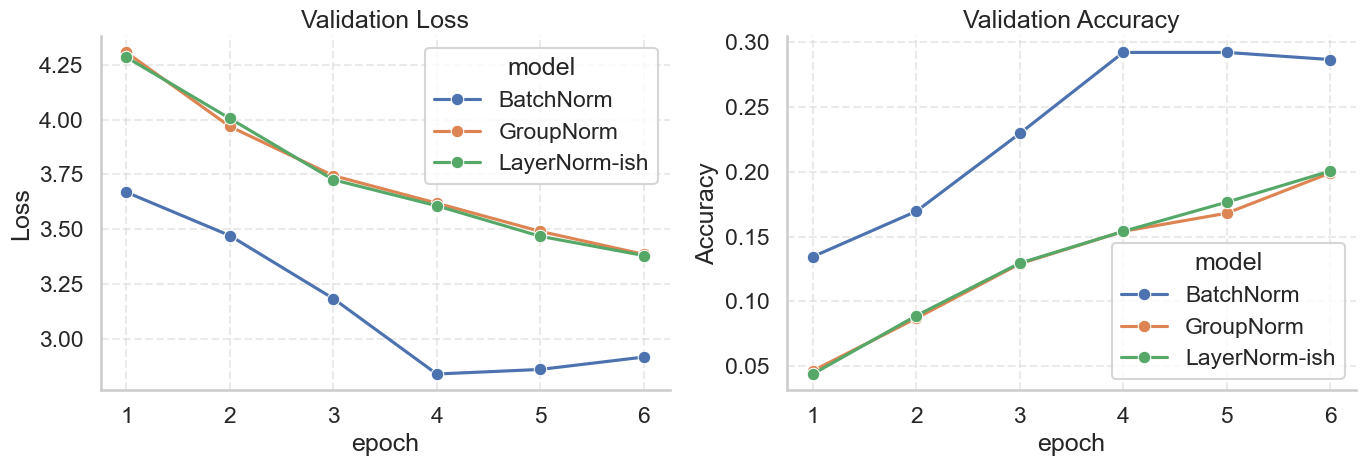

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for metric, ax in zip(['loss', 'accuracy'], axes):
    subset = metrics_df[(metrics_df['metric'] == metric) & (metrics_df['split'] == 'val')]
    sns.lineplot(data=subset, x='epoch', y='value', hue='model', marker='o', ax=ax)
    ax.set_title(f'Validation {metric.title()}')
    ax.set_ylabel(metric.title())
    ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 9. Activation Statistics
Means and standard deviations per layer show how each normalization keeps representations balanced—or not.

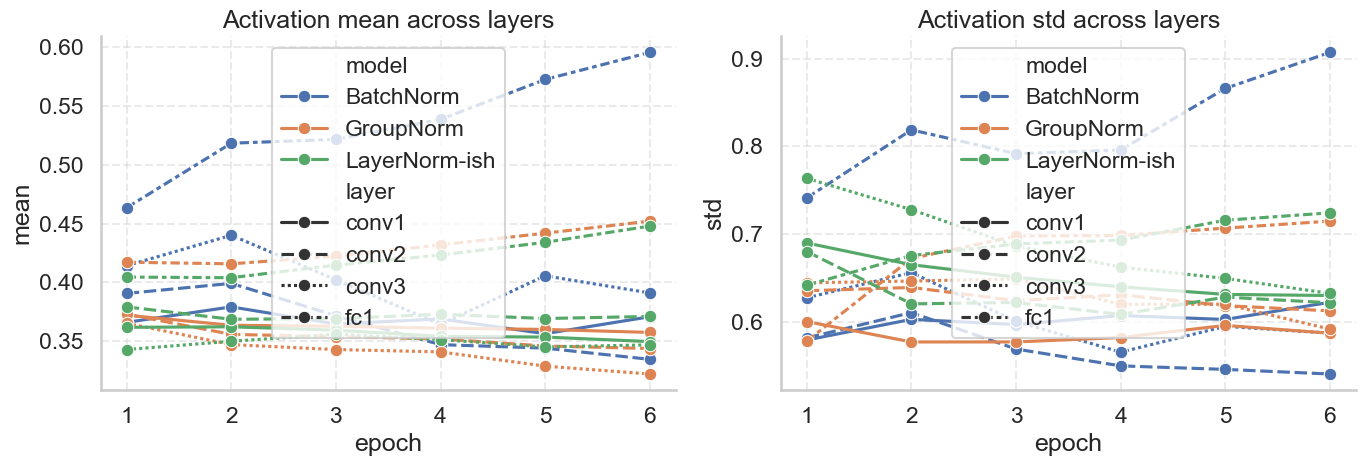

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for metric, ax in zip(['mean', 'std'], axes):
    sns.lineplot(data=activation_df[activation_df['layer'].isin(['conv1', 'conv2', 'conv3', 'fc1'])],
                 x='epoch', y=metric, hue='model', style='layer', marker='o', ax=ax)
    ax.set_title(f'Activation {metric} across layers')
    ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 10. Activation Distributions in Deeper Layers
Kernel density estimates for the third conv block reveal BatchNorm’s tight clustering, GroupNorm’s moderate spread, and the wide, shifting tails from LayerNorm-style normalization.

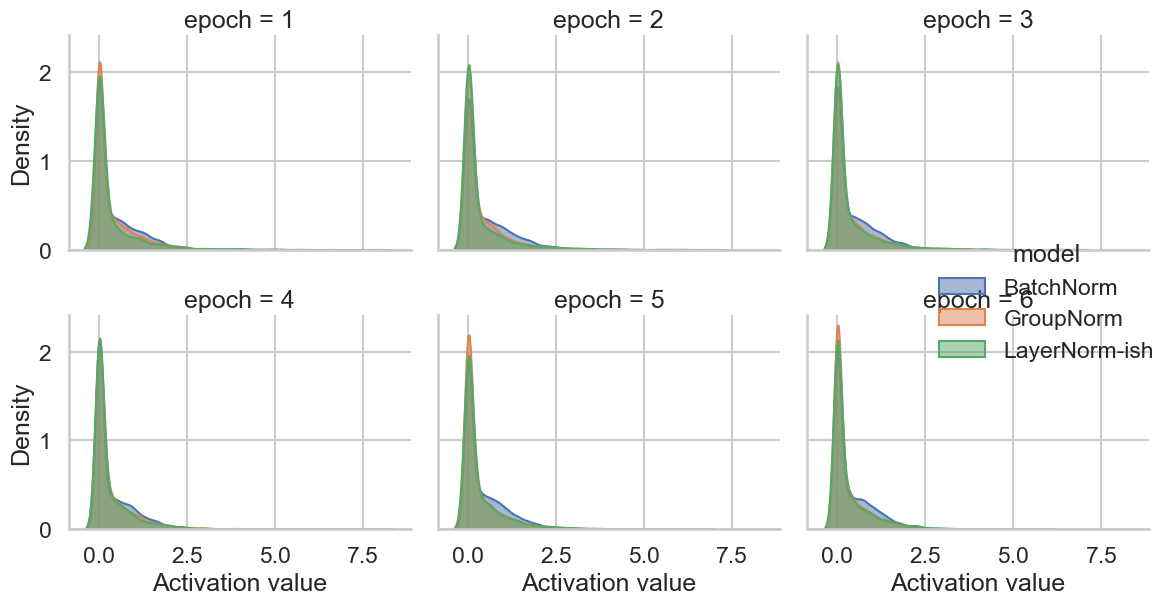

In [10]:
conv3_samples = [rec for rec in activation_samples if rec['layer'] == 'conv3']
frames = []
for rec in conv3_samples:
    frames.append(pd.DataFrame({'value': rec['values'], 'model': rec['model'], 'epoch': rec['epoch']}))
conv3_df = pd.concat(frames, ignore_index=True)
conv3_df['epoch'] = conv3_df['epoch'].astype(int)

g = sns.FacetGrid(conv3_df, col='epoch', hue='model', sharex=True, sharey=True, col_wrap=3, height=3.2)
g.map(sns.kdeplot, 'value', fill=True, alpha=0.5)
g.add_legend()
for ax in g.axes.flatten():
    ax.set_xlabel('Activation value')
plt.tight_layout()
plt.show()

## 11. Gradient Norm Heatmaps
Average gradient magnitudes per layer underscore how normalization choices affect signal propagation: BatchNorm keeps late-layer gradients healthy, while the LayerNorm variant suffers decay.

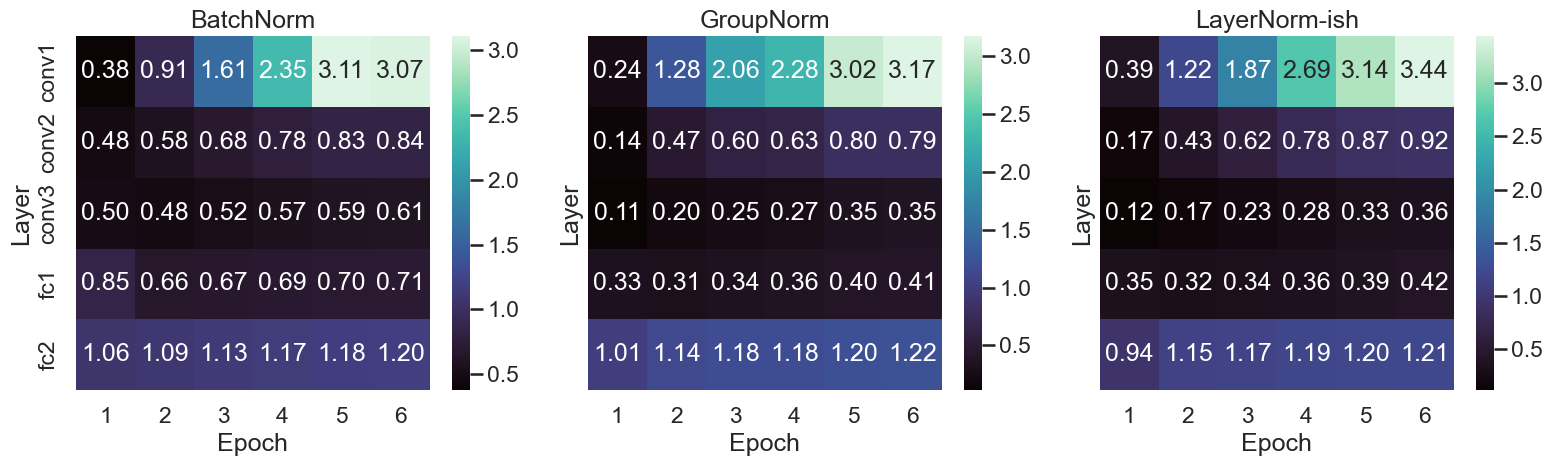

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, (model_name, group) in zip(axes, gradient_df.groupby('model')):
    pivot = group.pivot(index='layer', columns='epoch', values='grad_norm').loc[TRACKED_LAYERS]
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='mako', ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Layer')
plt.tight_layout()
plt.show()

## Key Takeaways
- BatchNorm remains the most stable on CIFAR-100, delivering the best validation accuracy and the most controlled activations.
- GroupNorm offers a competitive middle ground, especially when batch sizes are constrained, while the LayerNorm-style variant struggles under this architecture.
- Activation and gradient diagnostics make it clear where each normalization shines or struggles, helping guide architecture choices beyond raw metrics.
- The instrumentation is reusable—swap in deeper networks, different datasets, or alternative norms (InstanceNorm, RMSNorm) to continue the comparison.